In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub 
import os

This notebook is just a baseline version for the actual detailed notebook. So, we can ignore 

- The manual NA fills instead of Pipeline + ColumnTransform methods.
- This will cause some data leak as we used the full train data's mean to fill in NA and during CV, the held-out fold's missing values were filled with a mean computed over the full train (including that fold), so the fold leaks into its own fill."
- The data-leak effect is small here, so the baseline CV score is mildly optimistic but trustworthy enough to iterate against

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [3]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv")
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

In [5]:
train.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [6]:
train.select_dtypes(exclude='object').columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

## EDA and Data Cleaning

In [7]:
# train = train.set_index("Id")
train.drop('Id',axis=1,inplace=True)
test.drop('Id',axis=1,inplace=True)

<Axes: >

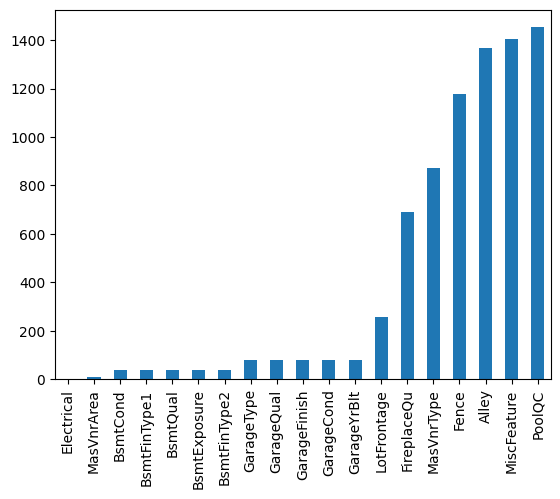

In [8]:
missing = train.isna().sum()
missing = missing[missing > 0]
missing.sort_values().plot.bar()

6 features has more than 50% of missig data

- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, `FirePlaceQu` , 5 Garage columns and 4 Basement columns - these columns have data description that mentions that the `NA` means no. So, we can reassign it to a new type "None"
- `LotFrontage`  is "linear feet of street connected to property." Almost every house touches a street, so a missing value is more likely unrecorded than truly zero. So, we can use mean of the column to fill in the `NA` rows.


In [9]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',]
train[none_cols] = train[none_cols].fillna("None")
test[none_cols] = test[none_cols].fillna("None")

lot_frontage_mean = train['LotFrontage'].mean()
train['LotFrontage'] = train['LotFrontage'].fillna(lot_frontage_mean)
test['LotFrontage'] = test['LotFrontage'].fillna(lot_frontage_mean)

garage_none_cols = ['GarageCond', 'GarageQual', 'GarageFinish', 'GarageYrBlt', 'GarageType']
train[garage_none_cols] = train[garage_none_cols].fillna("None")
test[garage_none_cols] = test[garage_none_cols].fillna("None")

basement_none_cols = ['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'BsmtCond']
train[basement_none_cols] = train[basement_none_cols].fillna("None")
test[basement_none_cols] = test[basement_none_cols].fillna("None")

- `MasVnrArea` and `MasVnrType` (type) are a pair. If a house has no masonry veneer, its type is "None" and its area should be 0 otherwise we can assign the `MasVnrType` type's mean.
- `Electrical` has one misssing value. So, we can drop that row.

In [10]:
group_means = train.groupby("MasVnrType", observed=False)["MasVnrArea"].transform("mean")
train['MasVnrArea'] = train['MasVnrArea'].fillna(group_means)

train.groupby("MasVnrType", observed=False).agg({"MasVnrArea":"mean"})

,MasVnrArea
MasVnrType,
BrkCmn,247.666667
BrkFace,259.008989
None,1.094907
Stone,239.304688


In [11]:
test_group_means = test['MasVnrType'].map(group_means)
test["MasVnrArea"] = test["MasVnrArea"].fillna(test_group_means)
test["MasVnrArea"] = test["MasVnrArea"].fillna(0)
test['MasVnrArea'].isna().sum()

np.int64(0)

We can observe that the `None` type we assigned for `MasVnrType` has a mean area of 1.09 which is a impossible. This is caused by assigning `None` to some value that had area value. So, Lets reassign it to 0. 

In [12]:
train.loc[train["MasVnrType"] == "None", "MasVnrArea"] = 0
test.loc[test["MasVnrType"] == "None", "MasVnrArea"] = 0

train.groupby("MasVnrType", observed=False).agg({"MasVnrArea":"mean"})

,MasVnrArea
MasVnrType,
BrkCmn,247.666667
BrkFace,259.008989
None,0.000000
Stone,239.304688


In [13]:
train.dropna(subset=['Electrical'], axis=0, inplace=True)

In [14]:
train.isna().sum().sum()

np.int64(0)

In [15]:
missing_test = test.isna().sum() 
missing_test[missing_test > 0].index

Index(['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'GarageArea',
       'SaleType'],
      dtype='object')

- `MSZoning`, `Utilities`, `Exterior1st`, `Exterior2nd`, `BsmtFullBath`, `BsmtHalfBath`, `KitchenQual`, `Functional`, `GarageCars` and `SaleType` - These columns are categorical and filled with the mode of training data.
- `BsmtFinSF1`, `BsmtFinSF1` - These columns are folled with 0 because `NA` means No Basement.
- `TotalBsmtSF`,`BsmtUnfSF`,`GarageArea` - These columns are filled with mean since they are quantative data.

In [16]:
mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 
             'BsmtFullBath', 'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'SaleType']
for col in mode_cols:
    train_mode = train[col].mode()[0]
    test[col] = test[col].fillna(train_mode)

mean_cols = ['TotalBsmtSF', 'BsmtUnfSF', 'GarageArea']
for col in mean_cols:
    train_mean = train[col].mean()
    test[col] = test[col].fillna(train_mean)

zero_cols = ['BsmtFinSF1', 'BsmtFinSF2']
test[zero_cols] = test[zero_cols].fillna(0)

In [17]:
test.isna().sum().sum()

np.int64(0)

In [18]:
train.reset_index(inplace=True,drop=True)

In [19]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [20]:
test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,120,0,None,MnPrv,None,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,0,None,None,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,None,MnPrv,None,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,None,None,None,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,...,144,0,None,None,None,0,1,2010,WD,Normal


In [21]:
train.shape

(1459, 80)

#### Change Data Types:

Memory Efficiency: It drastically reduces the memory footprint of your DataFrame if you have text columns with repeating values (like MSZoning or Neighborhood).

Machine Learning: Many modern algorithms (like LightGBM or CatBoost) can handle the category dtype natively without requiring manual one-hot encoding.

Since it holds no predictive value for pricing a house, Lets reassign `Id` column to the dataframe's id.

In [22]:
cat_feats = train.select_dtypes(include='object').columns
train[cat_feats] = train[cat_feats].astype('category')
test[cat_feats] = test[cat_feats].astype('category')
train.select_dtypes('category').columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')

## Target Analysis

<Axes: >

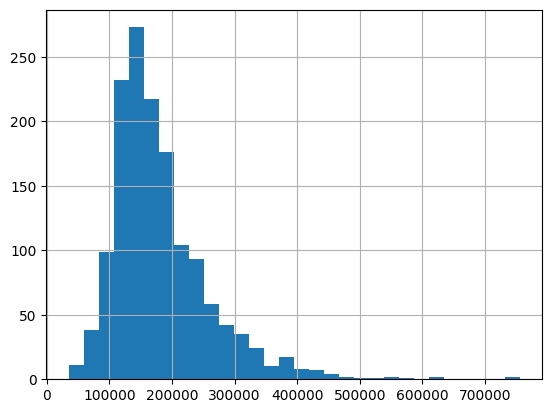

In [23]:
train['SalePrice'].hist(bins=30)

- Its unimodal and strong right skewed with a long tail.
- It has a peak at 140K-150K and most of the data is concentrated between 100K-250K
- `log1p` is required for this target variable.

Note: The Kaggle loss metric is RMSE on log(SalePrice). So predicting in log space means our model optimizes the exact thing it's scored on.

<Axes: >

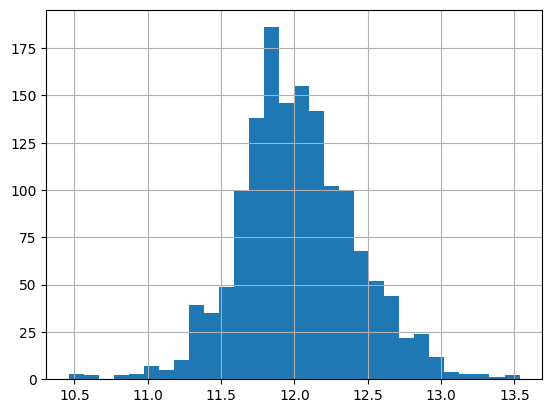

In [24]:
np.log1p(train['SalePrice']).hist(bins=30)

- This is more normally distributed and the long tail is shrunk.
- log space penalizes proportional error, so big houses stop dominating the loss. 

## Encoding 

Note: `get_dummies()` on train and test separately will return inconsistent data because a category present in train but absent in test (or vice versa) produces different columns which will result in column misaligned matrice.

In [25]:
train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,8,2007,WD,Normal,175000
1455,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1456,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1457,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,4,2010,WD,Normal,142125


In [26]:
y = np.log1p(train['SalePrice'])
train_size = train.shape[0]

data = pd.concat([train,test],keys=['train','test'])
data_size = data.shape[0]
cat_feats = data.select_dtypes(include=['category','object']).columns

data = pd.get_dummies(data,columns=cat_feats,drop_first=True)
X = data.drop('SalePrice',axis=1)
bool_cols = X.select_dtypes('boolean').columns
X[bool_cols] = X[bool_cols].astype(int)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

X_train.shape, X_test.shape, y.shape

((1459, 361), (1459, 361), (1459,))

Note: We deleted one Electrical-null row during data cleaning in train data.

In [27]:
from sklearn.linear_model import Ridge, LinearRegression, ElasticNet, Lasso
from sklearn.model_selection import cross_val_score, cross_val_predict

for name, model in [('OLS',LinearRegression()),
                    ('Ridge',Ridge(alpha=1.0)),
                    ('Lasso',Lasso(alpha=0.001)),
                    ('Elastic',ElasticNet(alpha=0.001,l1_ratio=0.05))] : 

    scores = cross_val_score(model, X_train, y, cv=5, scoring="neg_root_mean_squared_error")
    print(f"{name}: {-scores.mean()}")

OLS: 0.19117180755105526
Ridge: 0.15029769788218633
Lasso: 0.14239004636167665
Elastic: 0.1464707123691413


In [28]:
def submit_test(pred,log=False):
    if log:
        sample['SalePrice'] = np.expm1(pred)
    else:
        sample['SalePrice'] = pred
    sample.to_csv('submission.csv',index=False)
    print("Submission completed !")
    return 

In [29]:
model = Lasso(alpha=0.001) 
m = model.fit(X_train,y)
pred_log = m.predict(X_test)
# submit_test(pred_log,True) 

## Decision Tree

In [30]:
X_train.shape, X_test.shape, y.shape

((1459, 361), (1459, 361), (1459,))

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

dt_model = DecisionTreeRegressor(max_depth=5) # no random seed 

dt_score = cross_val_score(dt_model, X_train, y, cv = 5, scoring='neg_root_mean_squared_error')
-dt_score.mean()

m = dt_model.fit(X_train,y)
pred_log = m.predict(X_test)

In [32]:
for i in range(1,10):
    dt_model = DecisionTreeRegressor(max_depth=i) # no random seed 
    dt_score = cross_val_score(dt_model, X_train, y, cv = 5, scoring='neg_root_mean_squared_error')
    print(-dt_score.mean())

0.2933202929409382
0.2538418196371175
0.229437874924549
0.20758314429887942
0.20171147748412138
0.19851161762684605
0.19625461264946745
0.19810811197027947
0.20055561254846097


In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
from sklearn.model_selection import GridSearchCV 

param_grid = {
    'max_depth' : [3,5,7,10,15,None], # None for max depth
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf': [1,2,5,10],
    'max_features': ['sqrt','log',None]
}

dt = DecisionTreeRegressor(random_state=42) 

grid = GridSearchCV(
    dt, param_grid, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1 # all available core 
)

grid.fit(X_train,y)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best params: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV RMSE: 0.18286633297933305


In [35]:
# submit_test(grid.predict(X_test),True)

#### Vizualize the tree

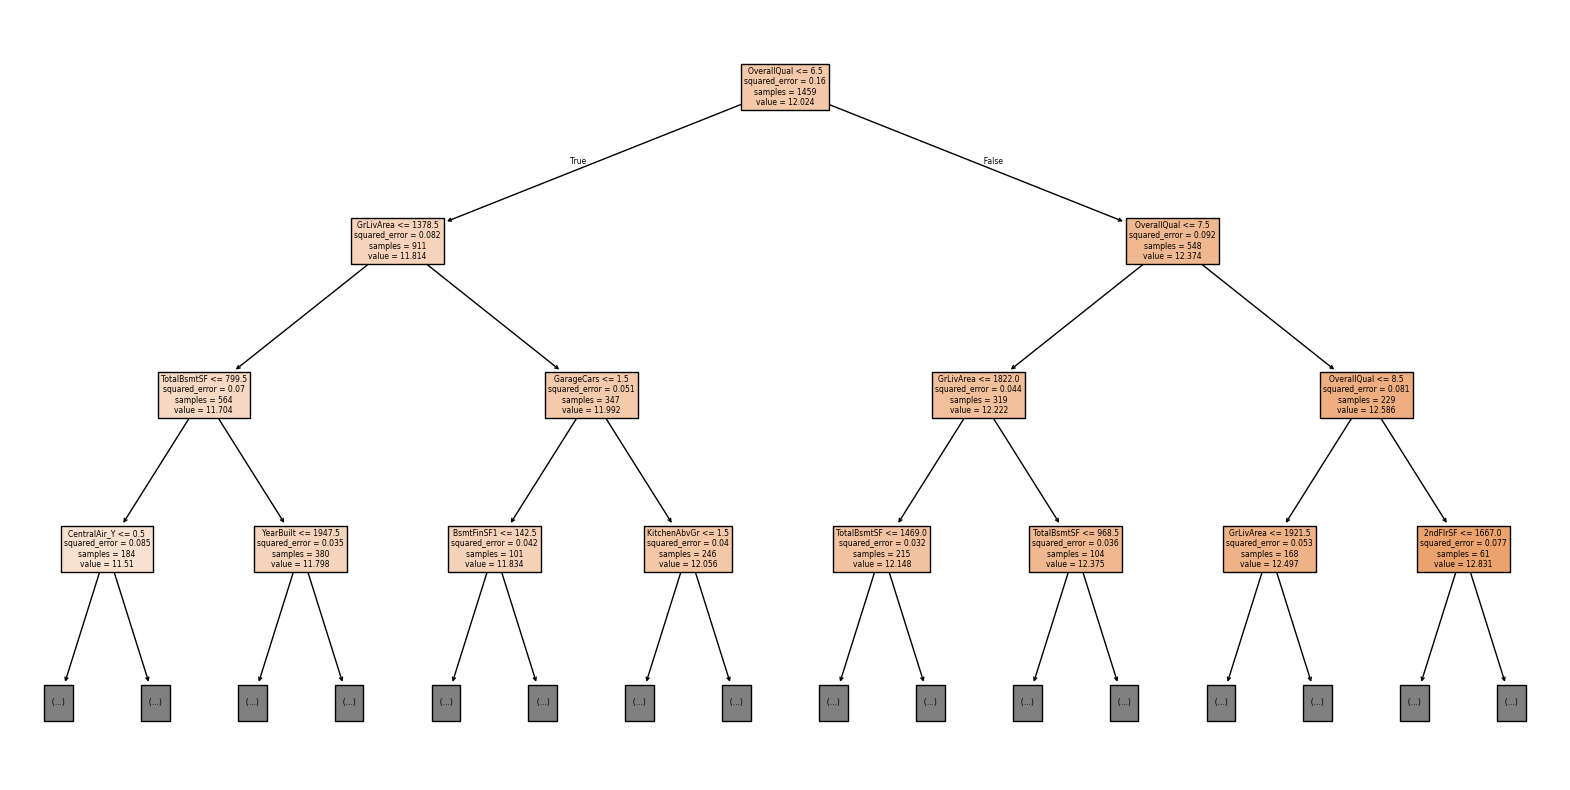

In [36]:
from sklearn.tree import  plot_tree
import matplotlib.pyplot as plt 

plt.figure(figsize=(20,10))
plot_tree(m, feature_names=X_train.columns, filled=True, max_depth=3)
plt.show()

## Random Forest

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100,300,500],
    'max_depth': [10,15,20,None],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt']
}

grid = RandomizedSearchCV(
    RandomForestRegressor(random_state=42,n_jobs=-1), 
    param_grid, 
    n_iter=10, 
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1, 
    cv=5, 
    verbose=0, 
    random_state=None, 
    return_train_score=False
)
grid.fit(X_train,y)

print(f'Best Params: {grid.best_params_}')
print(f"Best Params: {-grid.best_score_}")


Best Params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best Params: 0.14772265474783058


In [ ]:
best_rf = grid.best_estimator_
pred_log = best_rf.predict(X_test)
# submit_test(pred_log, True) 

## AdaBoost 

In [46]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

param_dist = {
    'estimator__max_depth': [3,5,8],
    'n_estimators':[50,100,150,200],
    'learning_rate':[0.01,0.05, 0.1,0.2]
}

grid = RandomizedSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=42), random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)


grid.fit(X_train,y)
print(f'Adaptive Boosting Params: {grid.best_params_}')
print(f'Adaptive Boosting Score: {-grid.best_score_:.5f}')
pred_log = ada_model.predict(X_test)

best_ada = grid.best_estimator_
submit_test(best_ada.predict(X_test), log=True)

Adaptive Boosting Params: {'n_estimators': 200, 'learning_rate': 0.1, 'estimator__max_depth': 8}
Adaptive Boosting Score: 0.14817
Submission completed !
